In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from core.signal.preprocess import *
from glob import glob
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
from core.nn.dataset import *
import core
import torchvision

In [2]:
# vctkds = torchaudio.datasets.VCTK_092(root="vctk/", download=False)
# maxLen = max([e[0].shape[1] for e in vctkds])
# for fn in tqdm(collectedFLAC):
#     x, sr = torchaudio.load(fn)
#     tform = torchaudio.transforms.Resample(sr, Fs)
#     x = tform(x)
#     # pad to maxLen
#     x = F.pad(x, (0, maxLen - x.shape[1]))
#     newFn = fn.replace("vctk/VCTK-Corpus-0.92", "vctk/resampled/VCTK-Corpus-0.92")
#     # make sure the directory exists
#     os.makedirs(os.path.dirname(newFn), exist_ok=True)
#     torchaudio.save(newFn, x, Fs)

In [3]:
#torchaudio.set_audio_backend("soundfile")

In [4]:
Fs = 16000
N = 200

vctkds = torchaudio.datasets.VCTK_092(root="vctk/", download=False)
ds2 = core.nn.dataset.VCTK_CSV("/home/mo/data/MICEMOUSE/gen/csv", Fs = Fs, resampleMethod="cubic")
paired_ds = core.nn.dataset.PairedAudioDataset(vctkds, ds2)
if os.path.exists("Ldiff.pt"):
    Ldiff = torch.load("Ldiff.pt")
else:
    Ldiff = []
    LA = []
    LB = []
    for A, B, _, _, _, _ in tqdm(paired_ds):
        Bs = B.shape[-1]
        As = A.shape[-1]
        Ldiff.append(Bs - As - 2 * Fs)
    Ldiff = torch.tensor(Ldiff, dtype=torch.float32)
    torch.save(Ldiff, "Ldiff.pt")

In [5]:
# remove outliers from L
time_threshold = 2 # seconds
idxx = torch.where(Ldiff < Fs * time_threshold)[0] # Mark outliers where the script decides to record more than necessary #TODO: investigate why this happens
filtered_paired_ds = torch.utils.data.Subset(paired_ds, idxx)
stat_subset = torch.utils.data.Subset(filtered_paired_ds, torch.randperm(len(filtered_paired_ds))[:N])
Lsubset = Ldiff[idxx]
print(f"Removed {len(Ldiff) - len(idxx)} outliers {100*(len(Ldiff) - len(idxx))/len(Ldiff):.2f}% of the dataset")
print(f"Remaining {len(paired_ds)} samples")
print(f"Using {len(stat_subset)} samples for statistics")
N_FFT = 2048 # From https://arxiv.org/pdf/1901.05061.pdf
N_HOP = 512 # Change from 1024 to 512 to get larger time resolution
margin = int(Ldiff[Ldiff < Fs * time_threshold].min().abs())
index_fn = torchvision.transforms.Lambda(lambda x: torch.cat((x[0], x[1][:, int(Fs - Lsubset.median().item()):int(Fs - Lsubset.median().item() + x[0].shape[-1] ) ])))
stft_fn = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    win_length=400,
    hop_length=160,
    n_mels=80,
    f_min=20,
    f_max=4000,
    # power=2.0,
    normalized=True,
)

Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Using 200 samples for statistics


In [6]:
lens = []
for A, B, _, _, _, _ in tqdm(filtered_paired_ds):
    lens.append(A.shape[-1])
    lens.append(B.shape[-1])
lens = torch.tensor(lens)
lens = lens.to(torch.float32)

  0%|          | 0/42486 [00:00<?, ?it/s]

100%|██████████| 42486/42486 [04:45<00:00, 149.02it/s]


Using 7 seconds of audio


Text(0.5, 0, 'Time (s)')

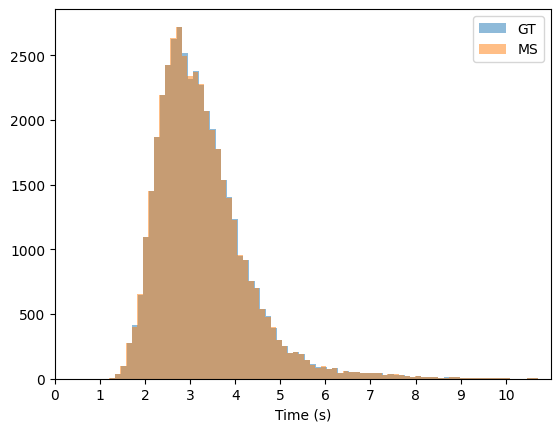

In [257]:
plt.hist(lens[::2], bins=100, alpha=0.5, label="GT")
plt.hist(lens[1::2] - 2 * Fs, bins=100, alpha=0.5, label="MS")
plt.legend()

# Find 95% percentile in time in seconds
nfpct = int(lens[1::2].quantile(0.95) / Fs)
T = nfpct * Fs
print(f"Using {nfpct} seconds of audio")
plt.xticks(np.arange(0, T + 4 * Fs, Fs), np.arange(0, nfpct + 4, 1))
plt.xlim(0, T + 4 * Fs)
plt.xlabel("Time (s)")

In [6]:
speaker_list = vctkds._speaker_ids
utterance_list = list(set([e[1] for e in vctkds._sample_ids]))
nSpeakers = len(speaker_list)
nUtterances = len(utterance_list)
onehot_speaker = lambda x: torch.eye(nSpeakers)[speaker_list.index(x)]
onehot_utterance = lambda x: torch.eye(nUtterances)[utterance_list.index(x)]
# Is this a clean way to do this? Hell nah
# Is this efficient? Yes

In [7]:
def trim_or_pad(x, T):
    if x.shape[-1] > T:
        return x[:T]
    else:
        # return F.pad(x, (0, T - x.shape[-1]))
        # pad at the beginning instead
        return F.pad(x, (T - x.shape[-1], 0))

def trim_or_pad2(x, T):
    if x.shape[-1] > T:
        return x[:, :T]
    else:
        return F.pad(x, (0, T - x.shape[-1]), mode="constant", value=0)

In [6]:
batch_size = 8
# Split into train and test
split = 0.85
lenTrain = int(len(filtered_paired_ds) * split)
lenTest = len(filtered_paired_ds) - lenTrain
# select lenTrain random indices
np.random.seed(0) # for reproducibility
idxtrain = np.random.choice(len(filtered_paired_ds), lenTrain, replace=False)
idxtest = np.setdiff1d(np.arange(len(filtered_paired_ds)), idxtrain)
train = torch.utils.data.Subset(filtered_paired_ds, idxtrain)
test = torch.utils.data.Subset(filtered_paired_ds, idxtest)

T = 5 * Fs
def collate(batch):
    N = len(batch)
    out_wavs = torch.zeros((N, T))
    out_mouse = torch.zeros((N, T))
    i = 0
    out_utterance = [ None ] * N
    out_speaker = [ None ] * N
    for e in batch:
        out_wavs[i] = trim_or_pad(e[0].squeeze(), T)
        out_mouse[i] = trim_or_pad(e[1].squeeze().mean(dim=0)[Fs:-Fs], T)
        out_wavs[i] = (out_wavs[i] - out_wavs[i].mean())/out_wavs[i].std()
        out_mouse[i] = (out_mouse[i] - out_mouse[i].mean())/out_mouse[i].std()
        out_utterance[i] = (e[-1])
        out_speaker[i] = (e[-2])
        i += 1
    return out_wavs, out_mouse, out_speaker, out_utterance


train_loader = torch.utils.data.DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collate)
test_loader = torch.utils.data.DataLoader(test, batch_size=batch_size, shuffle=False, collate_fn=collate)

In [7]:
B = next(iter(train_loader))

In [8]:
stft_fn(B[0]).shape, stft_fn(B[1]).shape

(torch.Size([8, 80, 501]), torch.Size([8, 80, 501]))

In [79]:
def plot_spectrogram(stft, title="Spectrogram", figax = None):
    magnitude = stft.abs()
    spectrogram = 20 * torch.log10(magnitude + 1e-8).numpy()
    if figax is None:
        figure, axis = plt.subplots(1, 1)
    else:
        figure, axis = figax
    img = axis.imshow(spectrogram, cmap="viridis", vmin=-100, vmax=100, origin="lower", aspect="auto")
    axis.set_title(title)
    plt.colorbar(img, ax=axis)

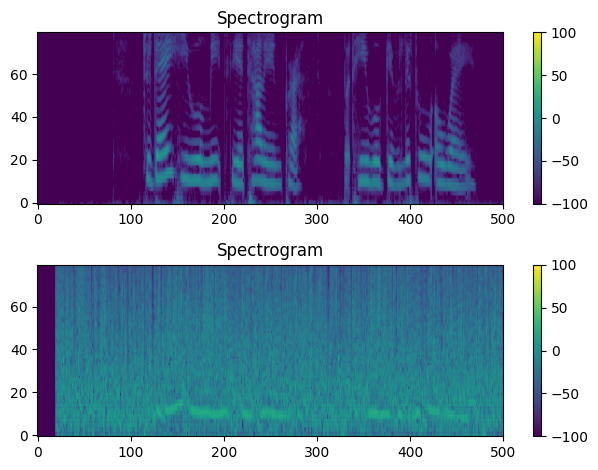

In [81]:
i = 0
figure, axis = plt.subplots(2, 1)
plot_spectrogram((stft_fn(B[0])[i]), figax = (figure, axis[0]))
plt.tight_layout()
plot_spectrogram(stft_fn(B[1])[i], figax = (figure, axis[1]))
plt.tight_layout()

In [143]:
from core.nn.whisper import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
encoder = AudioEncoder(n_mels=80, n_ctx=251, n_state=96, n_head = 6, n_layer=4).to(device)
flatten = nn.Flatten()
class permute (nn.Module):
    def forward(self, x):
        # x is (batch, n_ctx, n_mels)
        return x.permute(0, 2, 1)
utteranceClassifier = nn.Sequential(
    encoder,
    permute(),
    nn.AvgPool1d(50),
    nn.Flatten(),
    nn.Linear(96 * 5, 256),
    nn.ReLU(),
    nn.Linear(256, nUtterances),
).to(device)
speakerClassifier = nn.Sequential(
    encoder,
    permute(),
    nn.AvgPool1d(50),
    nn.Flatten(),
    nn.Linear(96 * 5, 256),
    nn.ReLU(),
    nn.Linear(256, nSpeakers),
).to(device)

In [145]:
N_EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = speakerClassifier
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
stft_fn_cuda = stft_fn = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=400,
    win_length=400,
    hop_length=160,
    n_mels=80,
    f_min=20,
    f_max=4000,
    # power=2.0,
    normalized=True,
).to(device)
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, mousewav, speaker_id, _) in train_loader:
            waveform = waveform.to(device)
            stft = stft_fn_cuda(waveform)
            # print(stft.shape)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_id.to(device)
            optimizer.zero_grad()
            output = net(stft)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")
torch.save(net.state_dict(), "net.pt")

Loss: 4.6735:   0%|          | 0/10 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [402]:
N_EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ConvNet2D(nSpeakers).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
stft_fn_cuda = torchaudio.transforms.Spectrogram(n_fft=N_FFT, hop_length=N_HOP, power=2).to(device)
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, speaker_id, _) in train_loader:
            waveform = waveform[:, 1:, :].to(device)
            stft = stft_fn_cuda(waveform)
            speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
            speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
            speaker_one_hot = speaker_id.to(device)
            optimizer.zero_grad()
            output = net(stft)
            loss = criterion(output, speaker_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")
torch.save(net.state_dict(), "net2.pt")

  0%|                                                                                                                                | 0/10 [00:00<?, ?it/s]


Loss: 0.0084: 100%|██████████| 10/10 [51:57<00:00, 311.76s/it]


In [403]:
N_EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ConvNet2D(nUtterances).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
stft_fn_cuda = torchaudio.transforms.Spectrogram(n_fft=N_FFT, hop_length=N_HOP, power=2).to(device)
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, utterance_id) in train_loader:
            waveform = waveform[:, 0, :].to(device)
            waveform = torch.stack([waveform, waveform], dim=1)
            stft = stft_fn_cuda(waveform)
            # print(stft.shape)
            utterance_id = torch.tensor([utterance_list.index(i) for i in utterance_id]).to(device)
            optimizer.zero_grad()
            output = net(stft)
            loss = criterion(output, utterance_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")
torch.save(net.state_dict(), "net3.pt")

Loss: 5.9133: 100%|██████████| 10/10 [51:17<00:00, 307.70s/it]


In [405]:
# Get Accuracy
net = ConvNet2D(nSpeakers).to(device)
net.load_state_dict(torch.load("net.pt"))
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for (waveform, speaker_id, _) in test_loader:
        waveform = waveform[:, 0, :].to(device)
        waveform = torch.stack([waveform, waveform], dim=1)
        stft = stft_fn_cuda(waveform)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        outputs = net(stft)
        _, predicted = torch.max(outputs.data, 1)
        total += speaker_id.size(0)
        correct += (predicted == speaker_id).sum().item()
print('Accuracy of the network on the test set: %d %%' % (100 * correct / total))

Accuracy of the network on the test set: 71 %


In [408]:
# Get Accuracy
net = ConvNet2D(nSpeakers).to(device)
net.load_state_dict(torch.load("net2.pt"))
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for (waveform, speaker_id, _) in test_loader:
        waveform = waveform[:, 1:, :].to(device)
        stft = stft_fn_cuda(waveform)
        speaker_one_hot = (torch.stack([onehot_speaker(i) for i in speaker_id]))
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        speaker_one_hot = speaker_id.to(device)
        outputs = net(stft)
        _, predicted = torch.max(outputs.data, 1)
        total += speaker_id.size(0)
        correct += (predicted == speaker_id).sum().item()
print('Accuracy of the network on the test set: %d %%' % (100 * correct / total))

Accuracy of the network on the test set: 55 %


In [427]:


# Get top-k accuracy
k = 5
net = ConvNet2D(nUtterances).to(device)
net.load_state_dict(torch.load("net3.pt"))
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for (waveform, _, utterance_id) in train_loader:
        waveform = waveform[:, 0, :].to(device)
        waveform = torch.stack([waveform, waveform], dim=1)
        stft = stft_fn_cuda(waveform)
        # print(stft.shape)
        utterance_id = torch.tensor([utterance_list.index(i) for i in utterance_id]).to(device)
        optimizer.zero_grad()
        outputs = net(stft)
        _, predicted = torch.topk(outputs.data, k=k, dim=1)
        total += utterance_id.size(0)
        correct += (predicted == utterance_id.view(-1, 1)).sum().item()
ratio3 = 100 * correct / total
print('Accuracy of the network on the test set: %d %%' % (100 * correct / total))

Accuracy of the network on the test set: 5 %


In [429]:
ratio3*nUtterances

2592.094259684878

In [ ]:
N_EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ConvNet2D(nUtterances).to(device)
net.load_state_dict(torch.load("net3.pt"))
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
stft_fn_cuda = torchaudio.transforms.Spectrogram(n_fft=N_FFT, hop_length=N_HOP, power=2).to(device)
with tqdm(range(N_EPOCHS)) as pbar:
    for epoch in pbar:
        for (waveform, _, utterance_id) in train_loader:
            waveform = waveform[:, 1:, :].to(device)
            stft = stft_fn_cuda(waveform)
            utterance_id = torch.tensor([utterance_list.index(i) for i in utterance_id]).to(device)
            optimizer.zero_grad()
            output = net(stft)
            loss = criterion(output, utterance_id)
            loss.backward()
            optimizer.step()
            pbar.set_description(f"Loss: {loss.item():.4f}")
torch.save(net.state_dict(), "net4.pt")

In [430]:
# Get Accuracy
net = ConvNet2D(nUtterances).to(device)
k = 5
net.load_state_dict(torch.load("net4.pt"))
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for (waveform, _, utterance_id) in test_loader:
        waveform = waveform[:, 1:, :].to(device)
        stft = stft_fn_cuda(waveform)
        # print(stft.shape)
        utterance_id = torch.tensor([utterance_list.index(i) for i in utterance_id]).to(device)
        optimizer.zero_grad()
        outputs = net(stft)
        _, predicted = torch.topk(outputs.data, k=k, dim=1)
        total += speaker_id.size(0)
        correct += (predicted == utterance_id.view(-1, 1)).sum().item()
ratio4 = 100 * correct / total
print('Accuracy of the network on the test set: %d %%' % (100 * correct / total))

Accuracy of the network on the test set: 3 %


In [431]:
nUtterances * ratio4

1804.9937264742784

In [426]:
0.03 / (correct / total)

3.2310810810810806

In [94]:
# save the models

torch.save(net.state_dict(), "convnet2d.pt")
torch.save(net_ds2.state_dict(), "convnet2d_ds2.pt")

In [95]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_loader):
        waveform = waveform.to(device)
        waveform = torch.cat([waveform, waveform], dim=1)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_loader.dataset) * 100:.2f}%")

  0%|          | 0/84 [00:00<?, ?it/s]

100%|██████████| 84/84 [00:08<00:00,  9.84it/s]

Accuracy: 93.67%


In [96]:
accuracy = 0 
with torch.no_grad():
    for (waveform, _, _, speaker_id, _) in tqdm(test_ds2_loader):
        waveform = waveform.to(device)
        speaker_id = torch.tensor([speaker_list.index(i) for i in speaker_id]).to(device)
        output = net_ds2(waveform)
        accuracy += (output.argmax(1) == speaker_id).sum().item()
print(f"Accuracy: {accuracy / len(test_ds2_loader.dataset) * 100:.2f}%")

100%|██████████| 84/84 [00:10<00:00,  8.26it/s]

Accuracy: 89.05%
